In [1]:
import jax
import jax.numpy as jnp
from jax import Array
from jax.typing import ArrayLike
from matplotlib import pyplot as plt
import numpy as np

In [2]:
def U(x):
    return jnp.power(x,2) - jnp.power(x,4)

In [3]:
S = jax.grad(U)

In [4]:
dS = jax.grad(S)

In [5]:
x = jnp.linspace(-1.,1.,101)

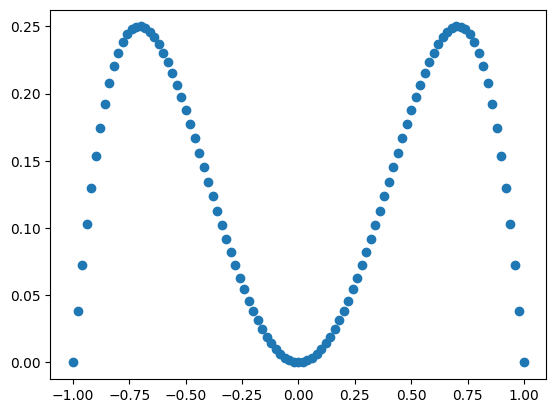

In [6]:
plt.scatter(x, U(x))

In [7]:
print("x shape: ", x.shape)
print("U(x) shape: ", U(x).shape)

x shape:  (101,)
U(x) shape:  (101,)


In [8]:
print("x shape: ", x.shape)
print("S(x) shape: ", jax.vmap(S)(x).shape)

x shape:  (101,)
S(x) shape:  (101,)


In [9]:
print("x shape: ", x.shape)
print("dS(x) shape: ", jax.vmap(dS)(x).shape)

x shape:  (101,)
dS(x) shape:  (101,)


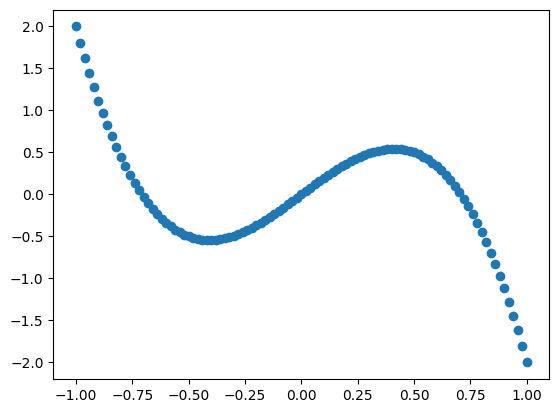

In [10]:
plt.scatter(x, jax.vmap(S)(x))

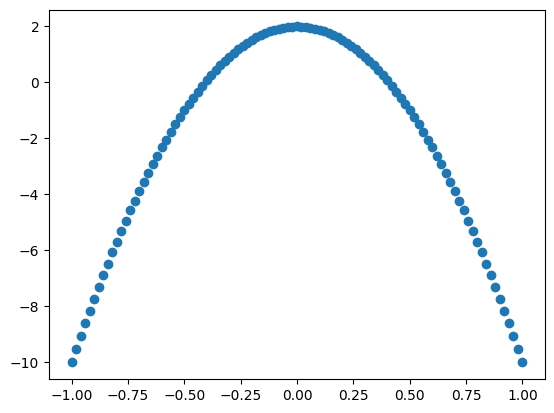

In [11]:
plt.scatter(x, jax.vmap(dS)(x))

# Definition of derivative functions for array arguments

In [12]:
Sarray = jax.vmap(S)
dSarray = jax.vmap(dS)

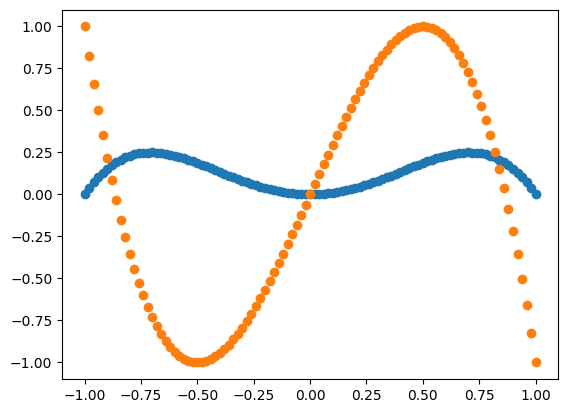

In [13]:
plt.scatter(x, x**2-x**4)
plt.scatter(x, Sarray(x) + x)

In [14]:
@jax.jit
def stepper(z, dz, dt):
    ''' Simple Euler integrator '''
    return z + dz * dt

In [15]:
key = jax.random.key(52)

In [16]:
key, subkey = jax.random.split(key)

In [17]:
deg = 6

In [18]:
def computeDerivatives(x,v,deg):
    
    p = jnp.polyfit(x, v, deg = deg)
    
    dv = 0
    
    for i in range(1,deg+1):
        dv += (i)*p[deg-i]*x**(i-1)  
    
    ddv = 0
    
    for i in range(2,deg+1):
        ddv += (i)*(i-1)*p[deg-i]*x**(i-2)  
    
    return dv,ddv

In [19]:
tEnd = 5
dt = 0.001
T = int(tEnd//dt)

targetT=T

N = 10000
x = jax.random.normal(subkey, shape=N)
logq = - x**2/2 # standard Gaussian

output = jnp.zeros((T+1, N, 3)) # x,v,phi

output = output.at[0,:,0].set(x[:])
output = output.at[0,:,1].set(logq[:])


for i in range(targetT):

    x = output[i,:,0]
    logq = output[i,:,1]

    Sq,dSq = computeDerivatives(x, logq, deg)

    dSv = dSarray(x)

    v = Sarray(x)-Sq
    
    output = output.at[i+1,:,0].set(stepper(x, v, dt))
    output = output.at[i+1,:,1].set(stepper(logq, dSq-dSv, dt))
    
    # stepping

Text(0, 0.5, '$x$')

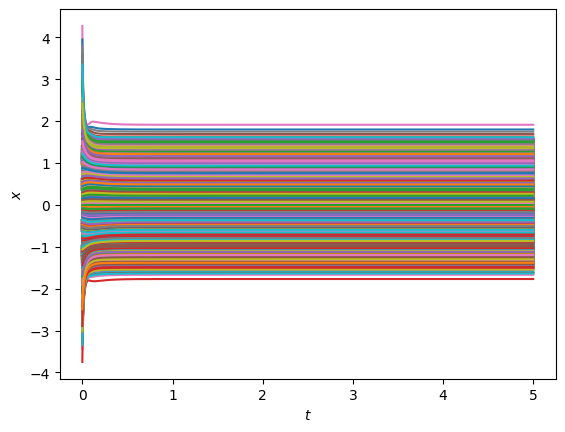

In [20]:
for i in range(N):
    plt.plot(jnp.linspace(0,tEnd,T+1),output[:targetT+1,i,0])

plt.xlabel('$t$')
plt.ylabel('$x$')


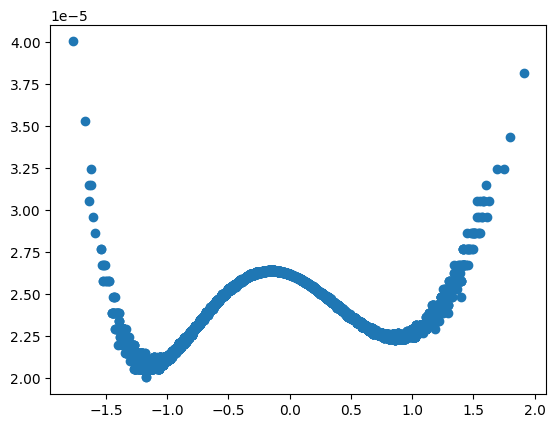

In [21]:
i = -1
x = output[i,:,0]
logq = output[i,:,1]
Sq,dSq = computeDerivatives(x, logq, deg)

dSv = dSarray(x)

v = Sq-Sarray(x)
plt.scatter(x,v)

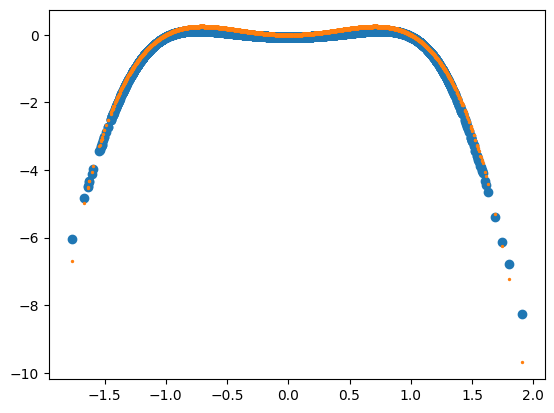

In [22]:
plt.scatter(x, logq, zorder = 0)
plt.scatter(x, U(x), 2, zorder = 1)

In [23]:
SMCsamples = np.load('SMC_samples_for_GL.npy')

(0.0, 60.0)

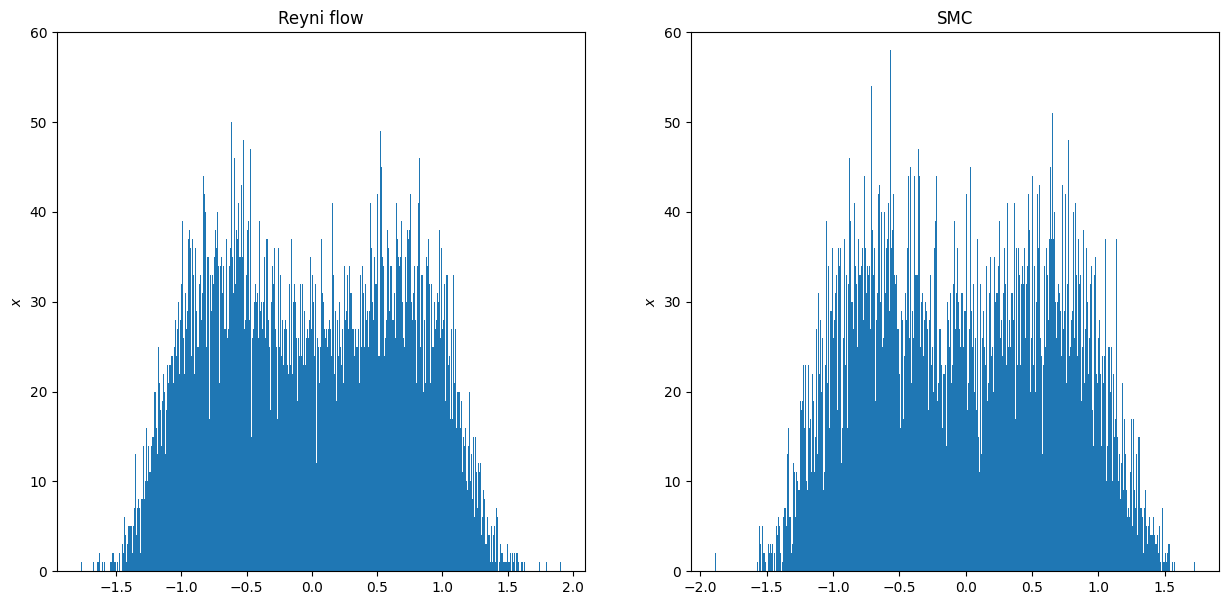

In [24]:
fig, ax = plt.subplots(1,2,figsize=[15, 7])

_=ax[0].hist(output[-1,:,0], bins=500)
ax[0].set_ylabel('histogram')
ax[0].set_ylabel('$x$')
ax[0].set_ylim([0,60])

ax[0].set_title('Reyni flow')

_=ax[1].hist(SMCsamples[:], bins=500)

ax[1].set_ylabel('histogram')
ax[1].set_ylabel('$x$')
ax[1].set_title('SMC')
ax[1].set_ylim([0,60])


In [25]:
from scipy.stats import ks_2samp

In [26]:
ks_2samp(output[-1,:,0], SMCsamples)

KstestResult(statistic=np.float64(0.0124), pvalue=np.float64(0.42554664596413133), statistic_location=np.float64(0.4848316797365354), statistic_sign=np.int8(-1))

In [27]:
def unNormalizedPdf(x):
    return np.exp(U(x))

In [28]:
# computing normalization via numerical quadratrure

from scipy.integrate import quad

In [29]:
Z = quad(unNormalizedPdf, -1000, 1000)

In [30]:
print(Z)

(2.761348981990351, 3.626430159782551e-08)


In [31]:
Z = quad(unNormalizedPdf, -500, 500)

In [32]:
print(Z)

(2.761348981990351, 3.626429804511183e-08)


In [33]:
Z = Z[0]

In [34]:
def normalizedPdf(x):
    return unNormalizedPdf(x)/Z

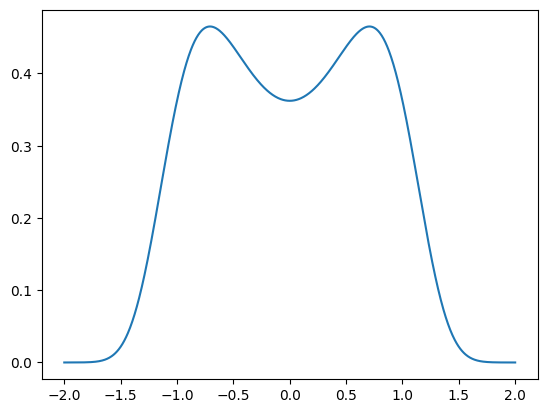

In [35]:
plt.plot(np.linspace(-2,2,1001), normalizedPdf(np.linspace(-2,2,1001)))

Text(0.5, 1.0, 'SMC')

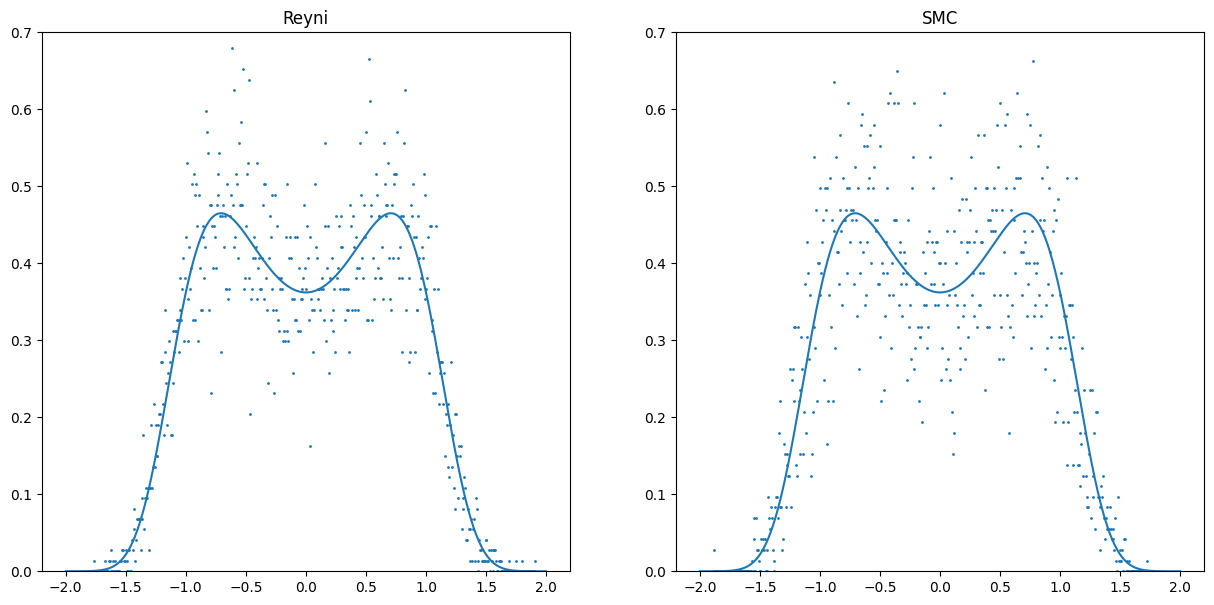

In [36]:
fig, ax = plt.subplots(1,2,figsize=[15, 7])

ax[0].plot(np.linspace(-2,2,1001), normalizedPdf(np.linspace(-2,2,1001)))
y,x = np.histogram(output[-1,:,0], bins=500)
y = y/sum(y)/(x[1]-x[0])
xc = 0.5*(x[:-1] + x[1:])
ax[0].scatter(xc, y, 1)
ax[0].set_ylim([0, 0.7])
ax[0].set_title('Reyni')

ax[1].plot(np.linspace(-2,2,1001), normalizedPdf(np.linspace(-2,2,1001)))
y,x = np.histogram(SMCsamples, bins=500)
y = y/sum(y)/(x[1]-x[0])
xc = 0.5*(x[:-1] + x[1:])
ax[1].scatter(xc, y, 1)
ax[1].set_ylim([0, 0.7])
ax[1].set_title('SMC')




In [37]:
discretizedN = 10001

In [38]:
discretized = np.linspace(-5, 5, discretizedN)

In [39]:
discretizedP = np.zeros(discretizedN+1)

In [40]:
for i in range(discretizedN+1):
    if i==0:
        discretizedP[i] = quad(unNormalizedPdf, -500, discretized[i])[0]
    elif i==discretizedN:
        discretizedP[i] = quad(unNormalizedPdf, discretized[-1], 500)[0]
    else:
        discretizedP[i] = quad(unNormalizedPdf, discretized[i-1], discretized[i])[0]

In [41]:
discretizedP /= np.sum(discretizedP)

In [42]:
index =  np.random.choice( discretizedN+1 , p = discretizedP, size=10000 )

In [43]:
xb = np.hstack([-500, discretized, 500])

In [44]:
xc =0.5*(xb[1:]+xb[:-1])

In [45]:
discretizedSamples = xc[index]

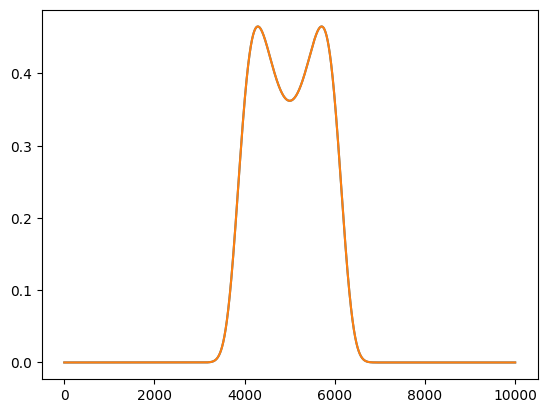

In [46]:
plt.plot(discretizedP/(xc[5]-xc[4]))
plt.plot(normalizedPdf(xc))

In [47]:
discretizedP.shape

(10002,)

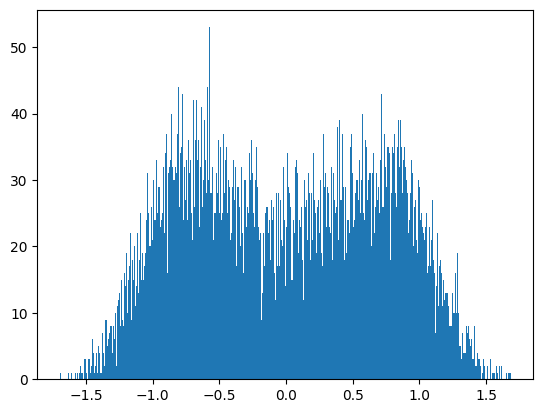

In [48]:
_=plt.hist(discretizedSamples, bins=500)


Text(0.5, 1.0, 'Discretized direct sampling')

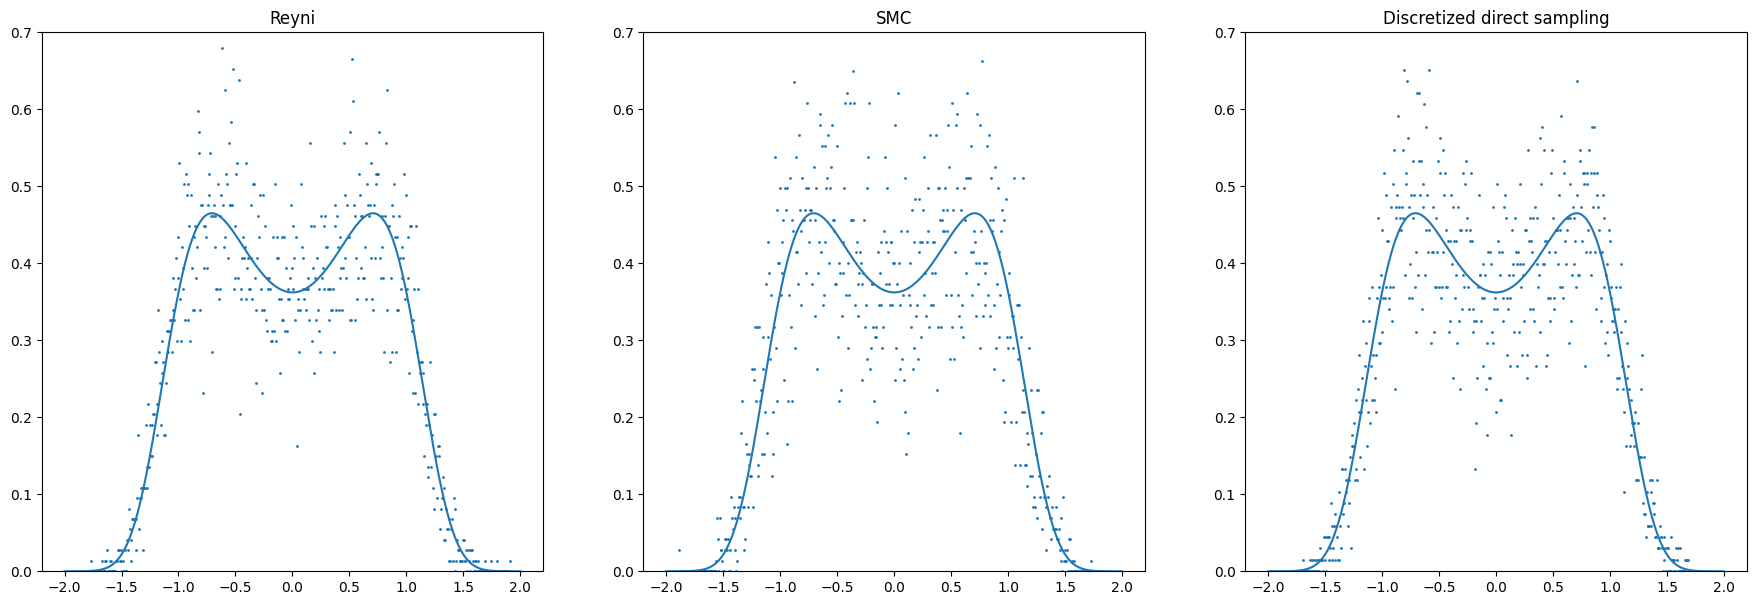

In [49]:
fig, ax = plt.subplots(1,3,figsize=[22, 7])

ax[0].plot(np.linspace(-2,2,1001), normalizedPdf(np.linspace(-2,2,1001)))
y,x = np.histogram(output[-1,:,0], bins=500)
y = y/sum(y)/(x[1]-x[0])
xc = 0.5*(x[:-1] + x[1:])
ax[0].scatter(xc, y, 1)
ax[0].set_ylim([0, 0.7])
ax[0].set_title('Reyni')

ax[1].plot(np.linspace(-2,2,1001), normalizedPdf(np.linspace(-2,2,1001)))
y,x = np.histogram(SMCsamples, bins=500)
y = y/sum(y)/(x[1]-x[0])
xc = 0.5*(x[:-1] + x[1:])
ax[1].scatter(xc, y, 1)
ax[1].set_ylim([0, 0.7])
ax[1].set_title('SMC')

ax[2].plot(np.linspace(-2,2,1001), normalizedPdf(np.linspace(-2,2,1001)))
y,x = np.histogram(discretizedSamples, bins=500)
y = y/sum(y)/(x[1]-x[0])
xc = 0.5*(x[:-1] + x[1:])
ax[2].scatter(xc, y, 1)
ax[2].set_ylim([0, 0.7])
ax[2].set_title('Discretized direct sampling')


# rejection-based sampling
Consider the proposal distribution to be a standard Gaussian, which decays slower than the Ginzburg-Landau potential

#### checking log density to determin the constant $M$

In [50]:
from scipy.stats import norm

In [51]:
gaussianLogPDF = norm(loc=0, scale=1).logpdf

In [52]:
def GLLogPDF(x):
    return x**2 - x**4  - np.log(Z)

In [53]:
x = np.linspace(-1.3, 1.3, 1000)

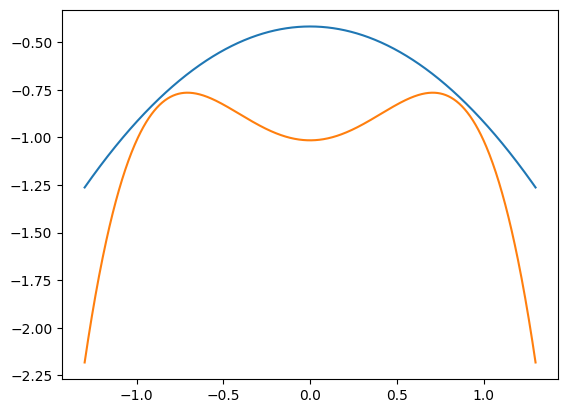

In [54]:
M = 1.65
plt.plot(x, jnp.log(M)+gaussianLogPDF(x))
plt.plot(x, GLLogPDF(x))

In [55]:
def rejectionSampling(key, N):

    successSamples = []

    firstBatch = True
    
    while len(successSamples) < N:

        key,subkey=jax.random.split(key)
        
        x = norm(loc=0.,scale=1.).rvs(1000)
        p = jnp.exp(GLLogPDF(x) - (jnp.log(M)+gaussianLogPDF(x)))
        u = jax.random.uniform(subkey, shape=1000)
    
        accept = u<p

        if firstBatch:
            successSamples = x[accept] 
            firstBatch = False
        else:
            
            successSamples = jnp.hstack((successSamples, x[accept]))

    return successSamples[:N]

In [56]:
rejectionSamples = rejectionSampling(key, 10000)

Text(0.5, 1.0, 'Reject sampling')

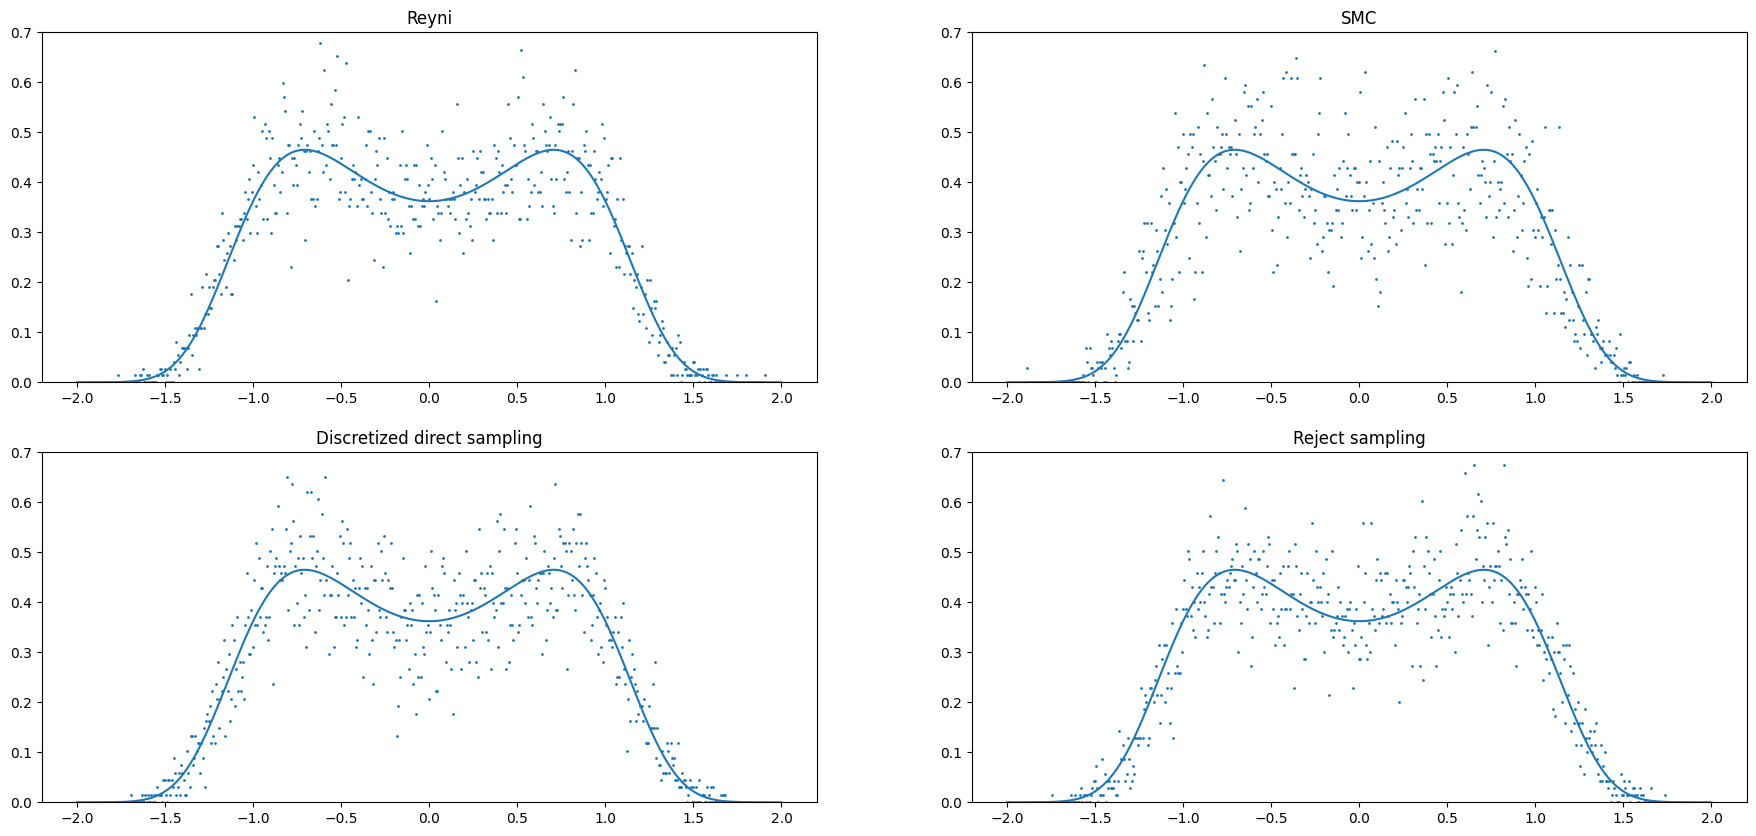

In [57]:
fig, ax = plt.subplots(2,2,figsize=[22, 10])
ax = ax.reshape([4,])

ax[0].plot(np.linspace(-2,2,1001), normalizedPdf(np.linspace(-2,2,1001)))
y,x = np.histogram(output[-1,:,0], bins=500)
y = y/sum(y)/(x[1]-x[0])
xc = 0.5*(x[:-1] + x[1:])
ax[0].scatter(xc, y, 1)
ax[0].set_ylim([0, 0.7])
ax[0].set_title('Reyni')

ax[1].plot(np.linspace(-2,2,1001), normalizedPdf(np.linspace(-2,2,1001)))
y,x = np.histogram(SMCsamples, bins=500)
y = y/sum(y)/(x[1]-x[0])
xc = 0.5*(x[:-1] + x[1:])
ax[1].scatter(xc, y, 1)
ax[1].set_ylim([0, 0.7])
ax[1].set_title('SMC')

ax[2].plot(np.linspace(-2,2,1001), normalizedPdf(np.linspace(-2,2,1001)))
y,x = np.histogram(discretizedSamples, bins=500)
y = y/sum(y)/(x[1]-x[0])
xc = 0.5*(x[:-1] + x[1:])
ax[2].scatter(xc, y, 1)
ax[2].set_ylim([0, 0.7])
ax[2].set_title('Discretized direct sampling')

ax[3].plot(np.linspace(-2,2,1001), normalizedPdf(np.linspace(-2,2,1001)))
y,x = np.histogram(rejectionSamples, bins=500)
y = y/sum(y)/(x[1]-x[0])
xc = 0.5*(x[:-1] + x[1:])
ax[3].scatter(xc, y, 1)
ax[3].set_ylim([0, 0.7])
ax[3].set_title('Reject sampling')

# 2-sample KS test

In [58]:
ReyniSamples = output[-1,:,0]

In [59]:
allSamples = [ReyniSamples, SMCsamples, discretizedSamples, rejectionSamples]

In [60]:
labels = ['Reyni', 'SMC', 'discretized', 'rejection']

In [61]:
for i,s1 in enumerate(allSamples):
    for j,s2 in enumerate(allSamples):
        if j>i:
            pVal = ks_2samp(s1, s2)[1]
            
            if pVal<0.05:
                print(labels[i]+' and '+labels[j]+f' are not from the same distribution with 95% confidence level (p value={pVal})')
            else:
                print('The hypothesis that '+labels[i]+' and '+labels[j]+' are from the same distribution cannot be rejected with 95% confidence level')
    

The hypothesis that Reyni and SMC are from the same distribution cannot be rejected with 95% confidence level
The hypothesis that Reyni and discretized are from the same distribution cannot be rejected with 95% confidence level
Reyni and rejection are not from the same distribution with 95% confidence level (p value=0.00470673563176954)
The hypothesis that SMC and discretized are from the same distribution cannot be rejected with 95% confidence level
SMC and rejection are not from the same distribution with 95% confidence level (p value=0.0003130040469736369)
discretized and rejection are not from the same distribution with 95% confidence level (p value=0.00470673563176954)
